Import Library

Churn dalam Dataset Sales and Marketing Customer
Apa itu Churn?
Churn artinya pelanggan yang berhenti menggunakan layanan atau tidak lagi melakukan pembelian kepada perusahaan.
Dalam dataset ini nilai Churn:

0 = pelanggan masih aktif (tidak churn)
1 = pelanggan sudah pergi/berhenti (churn)


Jadi project ini menangani apa?
Project ini bukan menangani penjualan (sales) secara langsung, tapi lebih ke mempertahankan pelanggan dengan cara:

"Memprediksi pelanggan mana yang berpotensi akan pergi sebelum mereka benar-benar pergi"




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# SMOTE untuk oversampling
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


Load Dataset

In [6]:
file_name = 'Sales - Marketing customer dataset.csv'
df = pd.read_csv(file_name)
print("Dataset berhasil dimuat!")
print(f"Ukuran dataset: {df.shape}")


Dataset berhasil dimuat!
Ukuran dataset: (4723, 30)


Exploratory Data Analysis (EDA)

### 1.1 Tampilkan 5 Baris Pertama

In [ ]:
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


### 1.2 Informasi Dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

### 1.3 Statistik Deskriptif

In [ ]:
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


### 1.4 Persentase Missing Value

In [ ]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_percent
}).sort_values('Percentage (%)', ascending=False)

print("Kolom dengan Missing Value:")
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nTotal kolom dengan missing value: {(missing > 0).sum()}")


Kolom dengan Missing Value:
                    Missing Count  Percentage (%)
coupon_code                  6133       40.886667
age                          1200        8.000000
total_spent                  1050        7.000000
gender                        738        4.920000
satisfaction_score            702        4.680000

Total kolom dengan missing value: 5


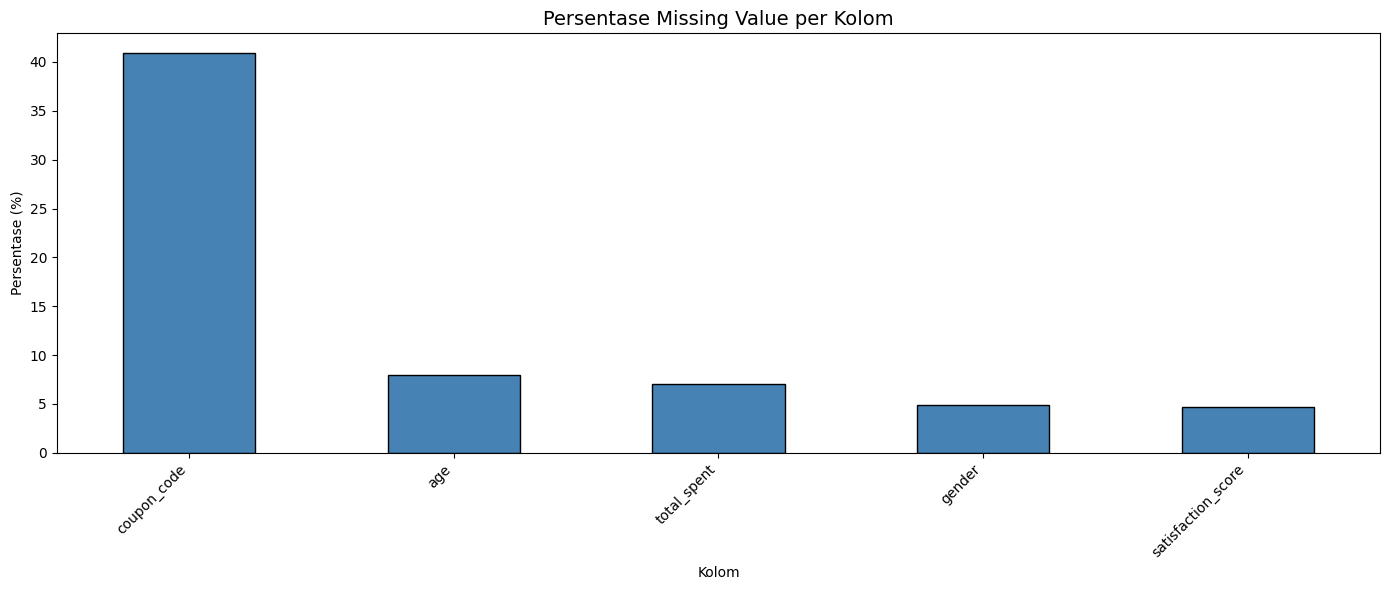

In [ ]:
# Visualisasi Missing Value - Diagram Batang
plt.figure(figsize=(14, 6))
missing_percent_sorted = missing_percent.sort_values(ascending=False)
cols_with_missing = missing_percent_sorted[missing_percent_sorted > 0]

if len(cols_with_missing) > 0:
    cols_with_missing.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Persentase Missing Value per Kolom', fontsize=14)
    plt.xlabel('Kolom')
    plt.ylabel('Persentase (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    plt.figure(figsize=(6, 3))
    plt.text(0.5, 0.5, 'Tidak ada Missing Value', ha='center', va='center',
             fontsize=14, color='green')
    plt.axis('off')
    plt.title('Persentase Missing Value per Kolom')
    plt.show()
    print("Tidak ada missing value dalam dataset.")


### 1.5 Distribusi Variabel Target (Churn)

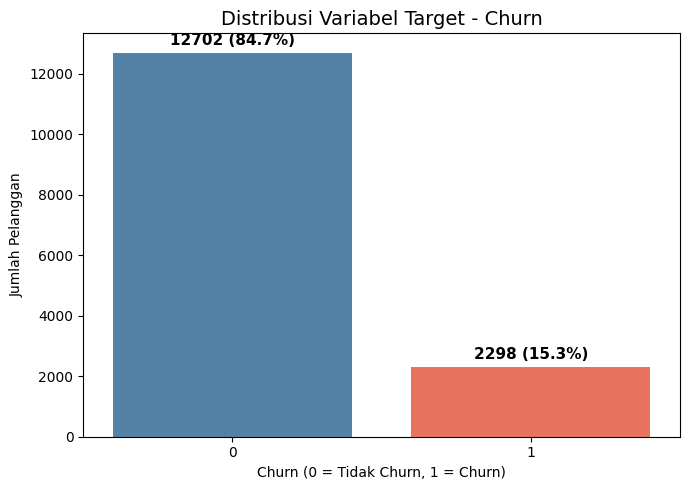

Distribusi Churn:
churn
0    12702
1     2298
Name: count, dtype: int64

Persentase Churn:
churn
0    84.68
1    15.32
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='churn', data=df, palette=['steelblue', 'tomato'])
plt.title('Distribusi Variabel Target - Churn', fontsize=14)
plt.xlabel('Churn (0 = Tidak Churn, 1 = Churn)')
plt.ylabel('Jumlah Pelanggan')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Distribusi Churn:")
print(df['churn'].value_counts())
print(f"\nPersentase Churn:")
print((df['churn'].value_counts(normalize=True) * 100).round(2))


### 1.6 Heatmap Korelasi Fitur Numerik

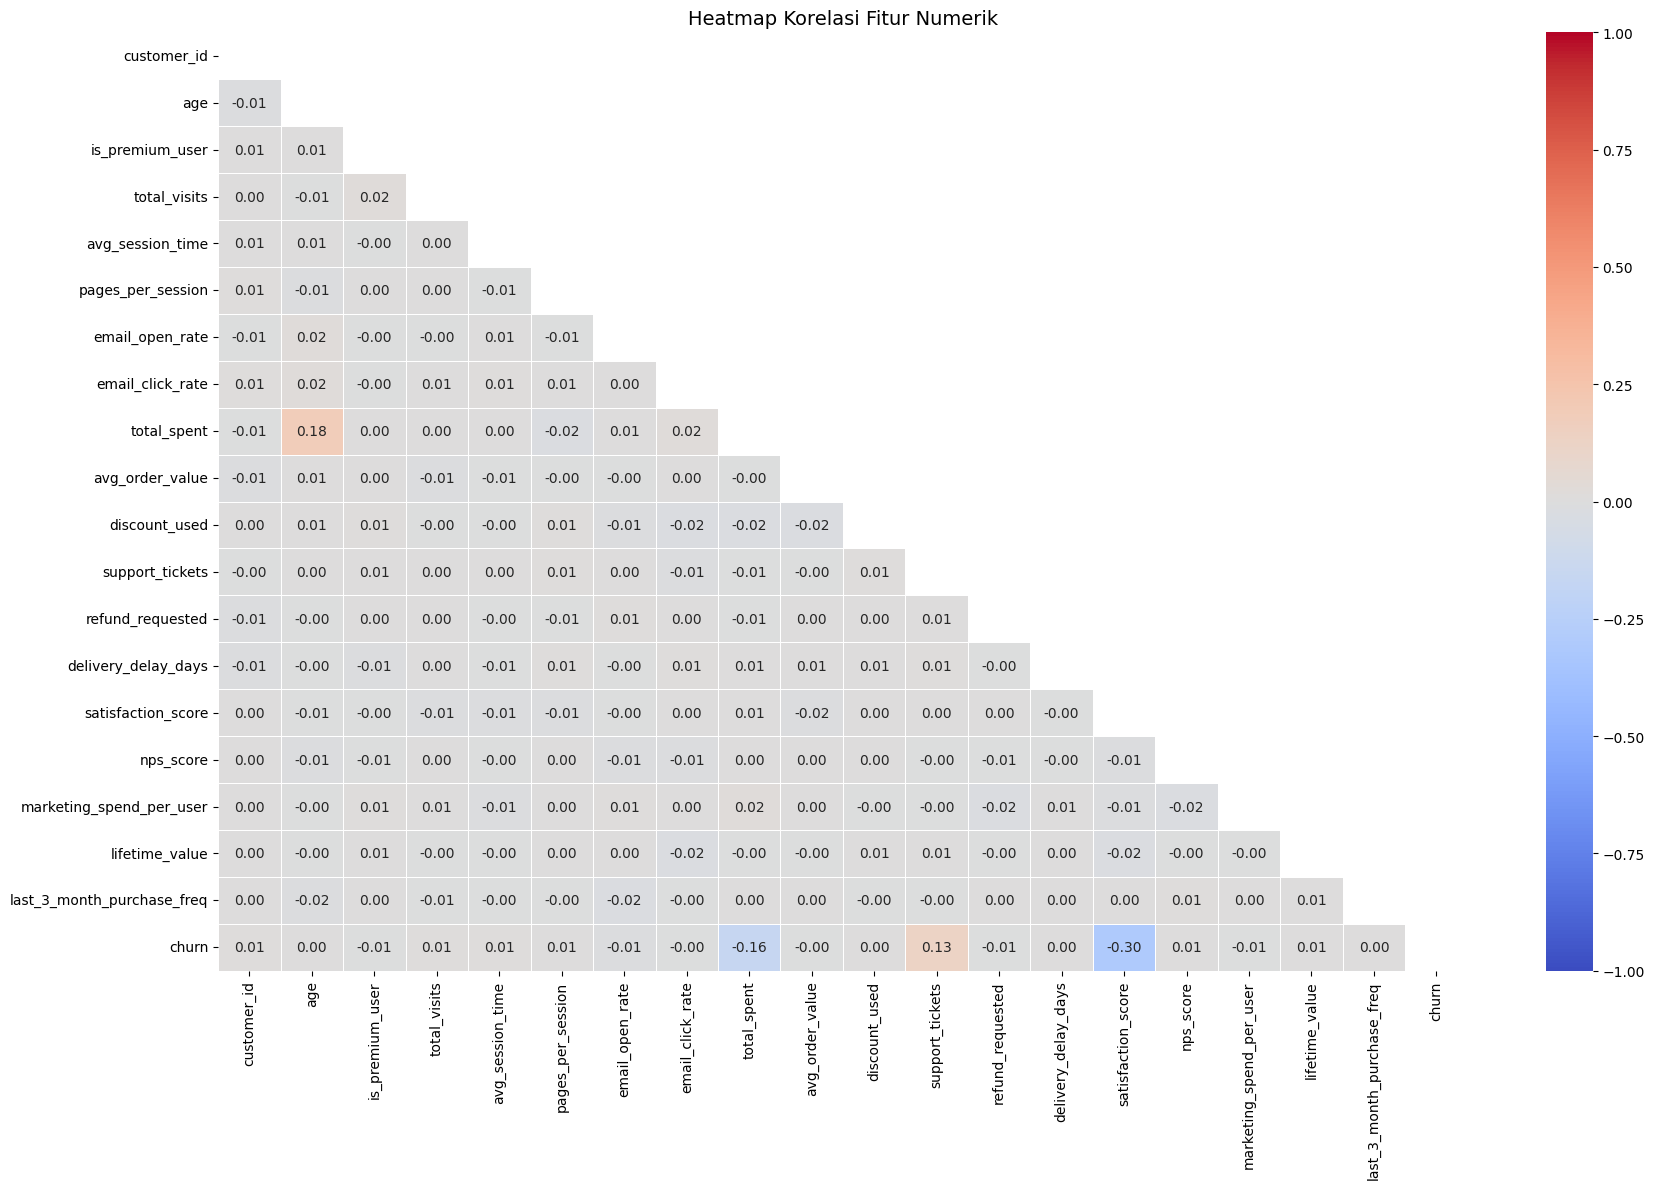


Top 10 Fitur dengan Korelasi Tertinggi terhadap Churn:
satisfaction_score          0.303588
total_spent                 0.163279
support_tickets             0.127910
total_visits                0.013212
customer_id                 0.012208
avg_session_time            0.012198
email_open_rate             0.008439
marketing_spend_per_user    0.007315
refund_requested            0.006959
lifetime_value              0.006250
Name: churn, dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(18, 12))
correlation = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation, dtype=bool))
sns.heatmap(
    correlation, mask=mask, cmap='coolwarm',
    annot=True, fmt='.2f', linewidths=0.5,
    vmin=-1, vmax=1, center=0
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi terhadap churn
if 'churn' in correlation.columns:
    churn_corr = correlation['churn'].drop('churn').abs().sort_values(ascending=False)
    print("\nTop 10 Fitur dengan Korelasi Tertinggi terhadap Churn:")
    print(churn_corr.head(10))


---
# 2. Direct Modeling

Unit Kompetensi Membangun model dasar dan menghasilkan prediksi awal.

Model dilatih langsung tanpa preprocessing (tanpa handling missing value, tanpa encoding khusus, tanpa scaling, tanpa hyperparameter tuning).  
Tiga model yang digunakan:
Model 1 — KNN (Konvensional)
Model 2 — Random Forest (Ensemble Bagging)
Model 3 — Voting Classifier LR + KNN + SVM (Ensemble Voting)


### 2.1 Persiapan Data untuk Direct Modeling

In [ ]:
df_direct = df.copy()

# Drop kolom ID dan datetime (tidak bisa langsung dipakai model tanpa preprocessing)
cols_drop = ['customer_id', 'signup_date', 'last_purchase_date']
cols_drop = [c for c in cols_drop if c in df_direct.columns]
df_direct.drop(cols_drop, axis=1, inplace=True)

# Encode minimal agar model bisa berjalan
cat_cols_d = df_direct.select_dtypes(include='object').columns
for col in cat_cols_d:
    le = LabelEncoder()
    df_direct[col] = le.fit_transform(df_direct[col].astype(str))

# Impute missing value agar tidak error
num_cols_d = df_direct.select_dtypes(include=['int64', 'float64']).columns
feat_cols_d = [c for c in num_cols_d if c != 'churn']
imp = SimpleImputer(strategy='mean')
df_direct[feat_cols_d] = imp.fit_transform(df_direct[feat_cols_d])

X_direct = df_direct.drop('churn', axis=1)
y_direct = df_direct['churn']

print(f"Shape X: {X_direct.shape}")
print(f"Shape y: {y_direct.shape}")


Shape X: (15000, 26)
Shape y: (15000,)


### 2.2 Train-Test Split

In [ ]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct, test_size=0.2, random_state=42, stratify=y_direct
)
print(f"Data Latih: {X_train_d.shape}")
print(f"Data Uji  : {X_test_d.shape}")


Data Latih: (12000, 26)
Data Uji  : (3000, 26)


### 2.3 Fungsi Evaluasi Model

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f'\n===== {model_name} =====')
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}


### 2.4 Model 1 — KNN (Konvensional)

In [ ]:
knn_d = KNeighborsClassifier()
knn_d.fit(X_train_d, y_train_d)
pred_knn_d = knn_d.predict(X_test_d)
print("KNN Direct — Selesai dilatih")


KNN Direct — Selesai dilatih


### 2.5 Model 2 — Random Forest (Ensemble Bagging)

In [ ]:
rf_d = RandomForestClassifier(random_state=42)
rf_d.fit(X_train_d, y_train_d)
pred_rf_d = rf_d.predict(X_test_d)
print("Random Forest Direct — Selesai dilatih")


Random Forest Direct — Selesai dilatih


### 2.6 Model 3 — Voting Classifier: LR + KNN + SVM (Ensemble Voting)

In [ ]:
# Ensemble Voting: gabungan Logistic Regression, KNN, dan SVM
voting_d = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True))          # SVM
    ],
    voting='soft'
)
voting_d.fit(X_train_d, y_train_d)
pred_voting_d = voting_d.predict(X_test_d)
print("Voting Classifier (LR + KNN + SVM) Direct — Selesai dilatih")


Voting Classifier (LR + KNN + SVM) Direct — Selesai dilatih


### 2.7 Evaluasi Model Direct


===== KNN (Direct) =====
Accuracy : 0.8437
Precision: 0.4800
Recall   : 0.2348
F1 Score : 0.3153

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      2540
           1       0.48      0.23      0.32       460

    accuracy                           0.84      3000
   macro avg       0.68      0.59      0.61      3000
weighted avg       0.81      0.84      0.82      3000



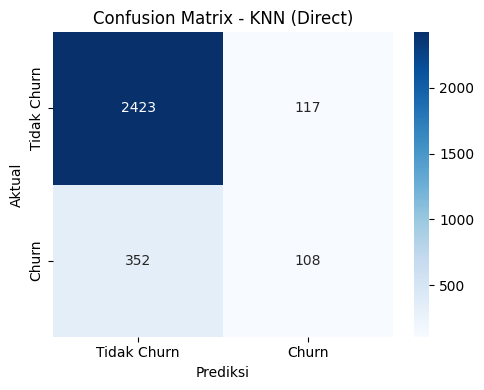


===== Random Forest (Direct) =====
Accuracy : 0.8503
Precision: 0.5189
Recall   : 0.3283
F1 Score : 0.4021

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      2540
           1       0.52      0.33      0.40       460

    accuracy                           0.85      3000
   macro avg       0.70      0.64      0.66      3000
weighted avg       0.83      0.85      0.84      3000



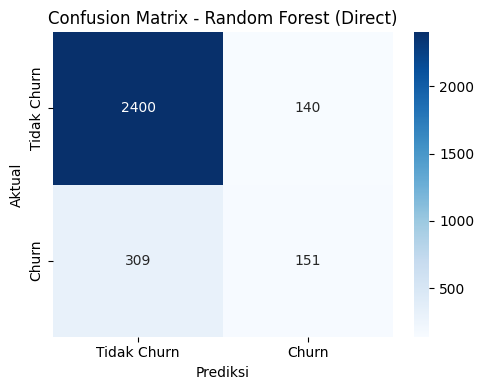


===== Voting Classifier LR+KNN+SVM (Direct) =====
Accuracy : 0.8500
Precision: 0.6190
Recall   : 0.0565
F1 Score : 0.1036

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.99      0.92      2540
           1       0.62      0.06      0.10       460

    accuracy                           0.85      3000
   macro avg       0.74      0.53      0.51      3000
weighted avg       0.82      0.85      0.79      3000



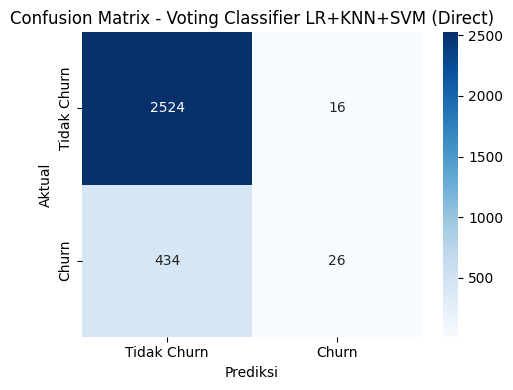


===== Ringkasan Performa Direct Modeling =====
                                Model  Accuracy  Precision   Recall       F1
                         KNN (Direct)  0.843667   0.480000 0.234783 0.315328
               Random Forest (Direct)  0.850333   0.518900 0.328261 0.402130
Voting Classifier LR+KNN+SVM (Direct)  0.850000   0.619048 0.056522 0.103586


In [ ]:
results_direct = []
results_direct.append(evaluate_model(y_test_d, pred_knn_d,    'KNN (Direct)'))
results_direct.append(evaluate_model(y_test_d, pred_rf_d,     'Random Forest (Direct)'))
results_direct.append(evaluate_model(y_test_d, pred_voting_d, 'Voting Classifier LR+KNN+SVM (Direct)'))

print("\n===== Ringkasan Performa Direct Modeling =====")
print(pd.DataFrame(results_direct).to_string(index=False))


---
# 3. Modeling dengan Preprocessing

Unit Kompetensi Membangun model dan menghasilkan prediksi dengan data yang bersih.

Tahapan preprocessing:
1. Hapus kolom tidak relevan
2. Ekstrak fitur dari kolom tanggal
3. Penanganan duplikasi
4. Penanganan missing value
5. Penanganan outlier (IQR Capping)
6. Encoding fitur kategorikal
7. Train-test split
8. Oversampling dengan SMOTE(menyeimbangkan kelas)
9. Scaling Normalisasi (MinMaxScaler) vs Standarisasi (StandardScaler)


### 3.1 Hapus Kolom Tidak Relevan

In [ ]:
df_prep = df.copy()

if 'customer_id' in df_prep.columns:
    df_prep.drop('customer_id', axis=1, inplace=True)
    print("customer_id dihapus (hanya identifier, tidak informatif)")

print(f"Shape setelah hapus kolom ID: {df_prep.shape}")


customer_id dihapus (hanya identifier, tidak informatif)
Shape setelah hapus kolom ID: (15000, 29)


### 3.2 Ekstrak Fitur dari Kolom Tanggal

In [ ]:
if 'signup_date' in df_prep.columns:
    df_prep['signup_date']  = pd.to_datetime(df_prep['signup_date'], errors='coerce')
    df_prep['signup_year']  = df_prep['signup_date'].dt.year
    df_prep['signup_month'] = df_prep['signup_date'].dt.month
    df_prep.drop('signup_date', axis=1, inplace=True)
    print("signup_date → signup_year, signup_month")

if 'last_purchase_date' in df_prep.columns:
    df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')
    df_prep['purchase_year']  = df_prep['last_purchase_date'].dt.year
    df_prep['purchase_month'] = df_prep['last_purchase_date'].dt.month
    df_prep.drop('last_purchase_date', axis=1, inplace=True)
    print("last_purchase_date → purchase_year, purchase_month")

print(f"Shape: {df_prep.shape}")


signup_date → signup_year, signup_month
last_purchase_date → purchase_year, purchase_month
Shape: (15000, 31)


### 3.3 Penanganan Duplikasi


In [ ]:
before = len(df_prep)
df_prep.drop_duplicates(inplace=True)
after  = len(df_prep)
print(f"Jumlah duplikat yang dihapus: {before - after}")
print(f"Shape setelah hapus duplikat : {df_prep.shape}")


Jumlah duplikat yang dihapus: 0
Shape setelah hapus duplikat : (15000, 31)


### 3.4 Penanganan Missing Value

In [10]:
print("Missing value sebelum penanganan:")
mv = df_prep.isnull().sum()
print(mv[mv > 0] if mv[mv > 0].any() else "Tidak ada missing value")

# Numerik → isi dengan median
for col in df_prep.select_dtypes(include=['int64','float64']).columns:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].median(), inplace=True)

# Kategorikal → isi dengan modus
for col in df_prep.select_dtypes(include='object').columns:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)

print(f"\nTotal missing value setelah penanganan: {df_prep.isnull().sum().sum()}")


Missing value sebelum penanganan:
Tidak ada missing value

Total missing value setelah penanganan: 0


### 3.5 Penanganan Outlier (IQR Capping)

In [9]:
# Re-establishing df_prep based on previous preprocessing steps due to NameError

# From cell MPC8fyGfxLQW (3.1 Hapus Kolom Tidak Relevan)
df_prep = df.copy()
if 'customer_id' in df_prep.columns:
    df_prep.drop('customer_id', axis=1, inplace=True)

# From cell fFxTrol-xarv (3.2 Ekstrak Fitur dari Kolom Tanggal)
if 'signup_date' in df_prep.columns:
    df_prep['signup_date']  = pd.to_datetime(df_prep['signup_date'], errors='coerce')
    df_prep['signup_year']  = df_prep['signup_date'].dt.year
    df_prep['signup_month'] = df_prep['signup_date'].dt.month
    df_prep.drop('signup_date', axis=1, inplace=True)

if 'last_purchase_date' in df_prep.columns:
    df_prep['last_purchase_date'] = pd.to_datetime(df_prep['last_purchase_date'], errors='coerce')
    df_prep['purchase_year']  = df_prep['last_purchase_date'].dt.year
    df_prep['purchase_month'] = df_prep['last_purchase_date'].dt.month
    df_prep.drop('last_purchase_date', axis=1, inplace=True)

# From cell mM4tImokTsfa (3.3 Penanganan Duplikasi)
df_prep.drop_duplicates(inplace=True)

# From cell ak3_93L_T4UE (3.4 Penanganan Missing Value)
for col in df_prep.select_dtypes(include=['int64','float64']).columns:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].median(), inplace=True)

for col in df_prep.select_dtypes(include='object').columns:
    if df_prep[col].isnull().sum() > 0:
        df_prep[col].fillna(df_prep[col].mode()[0], inplace=True)

# Original code from cell H_feMwnXUEUc
num_features = [c for c in df_prep.select_dtypes(include=['int64','float64']).columns
                if c != 'churn']

for col in num_features:
    Q1  = df_prep[col].quantile(0.25)
    Q3  = df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    df_prep[col] = df_prep[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

print(f"Outlier di-cap menggunakan metode IQR pada {len(num_features)} fitur numerik")
print(f"Shape: {df_prep.shape}")

Outlier di-cap menggunakan metode IQR pada 18 fitur numerik
Shape: (4723, 31)


### 3.6 Encoding Fitur Kategorikal

In [ ]:
cat_cols = df_prep.select_dtypes(include='object').columns.tolist()
print(f"Kolom kategorikal: {cat_cols}")

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_prep[col] = le.fit_transform(df_prep[col].astype(str))
    label_encoders[col] = le

print("Encoding selesai")


Kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'coupon_code', 'payment_method']
Encoding selesai


### 3.7 Pisahkan Fitur dan Target

In [ ]:
X = df_prep.drop('churn', axis=1)
y = df_prep['churn']

print(f"Fitur prediktor (X): {X.shape}")
print(f"Target (y)         : {y.shape}")
print(f"\nDistribusi kelas sebelum oversampling:")
print(y.value_counts())


Fitur prediktor (X): (15000, 30)
Target (y)         : (15000,)

Distribusi kelas sebelum oversampling:
churn
0    12702
1     2298
Name: count, dtype: int64


### 3.8 Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Data Latih: {X_train.shape}")
print(f"Data Uji  : {X_test.shape}")


Data Latih: (12000, 30)
Data Uji  : (3000, 30)


### 3.9 Oversampling dengan SMOTE

Tujuan Menyeimbangkan distribusi kelas pada data latih agar model tidak bias terhadap kelas mayoritas.

SMOTE (Synthetic Minority Oversampling Technique)dipilih karena menghasilkan sampel sintetis baru (bukan sekadar menduplikasi) sehingga model lebih baik dalam mengenali kelas minoritas (Churn = 1).

>SMOTE hanya diterapkan pada data latih, bukan data uji, untuk menghindari data leakage.


Distribusi kelas SEBELUM SMOTE:
churn
0    10162
1     1838
Name: count, dtype: int64

Distribusi kelas SETELAH SMOTE:
churn
1    10162
0    10162
Name: count, dtype: int64


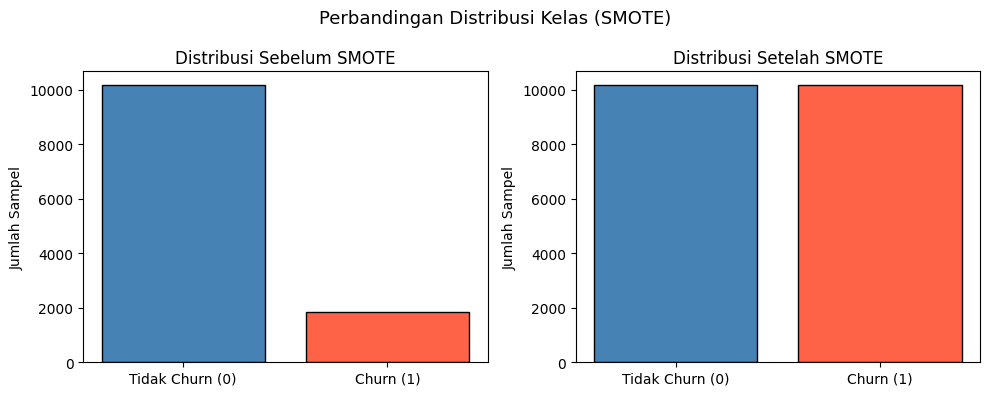

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Distribusi kelas SEBELUM SMOTE:")
print(y_train.value_counts())
print(f"\nDistribusi kelas SETELAH SMOTE:")
print(pd.Series(y_train_sm).value_counts())

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'],
            y_train.value_counts().sort_index(),
            color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Distribusi Sebelum SMOTE')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(['Tidak Churn (0)', 'Churn (1)'],
            pd.Series(y_train_sm).value_counts().sort_index(),
            color=['steelblue','tomato'], edgecolor='black')
axes[1].set_title('Distribusi Setelah SMOTE')
axes[1].set_ylabel('Jumlah Sampel')

plt.suptitle('Perbandingan Distribusi Kelas (SMOTE)', fontsize=13)
plt.tight_layout()
plt.show()


### 3.10 Scaling Fitur

**Scaling dilakukan setelah train-test split dan SMOTE** untuk mencegah data leakage.

Dua metode scaling dibandingkan:
-Normalisasi (MinMaxScaler) Mengubah skala fitur ke rentang [0, 1]. Cocok jika distribusi data tidak normal dan tidak ada outlier ekstrem.
- Standarisasi (StandardScaler) Mengubah fitur sehingga mean = 0 dan std = 1. Cocok untuk model yang sensitif terhadap jarak seperti KNN dan SVM.

Untuk model KNN dan Voting Classifier (LR+KNN+SVM) digunakan Standarisasi, karena kedua model ini berbasis jarak/gradien.  
Untuk model Random Forest tidak memerlukan scaling karena berbasis pohon keputusan.


In [ ]:
# Standarisasi (StandardScaler) — digunakan untuk KNN dan Voting (LR+KNN+SVM)
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train_sm)
X_test_std  = scaler_std.transform(X_test)

# Normalisasi (MinMaxScaler) — sebagai perbandingan
scaler_norm = MinMaxScaler()
X_train_norm = scaler_norm.fit_transform(X_train_sm)
X_test_norm  = scaler_norm.transform(X_test)

print("Standarisasi (StandardScaler) selesai")
print(f"   X_train_std — mean ≈ {X_train_std.mean():.4f}, std ≈ {X_train_std.std():.4f}")
print(f"   X_test_std  — min={X_test_std.min():.3f}, max={X_test_std.max():.3f}")

print("\nNormalisasi (MinMaxScaler) selesai")
print(f"   X_train_norm — min={X_train_norm.min():.4f}, max={X_train_norm.max():.4f}")
print(f"   X_test_norm  — min={X_test_norm.min():.4f}, max={X_test_norm.max():.4f}")

print("\n Random Forest tidak memerlukan scaling (berbasis pohon keputusan).")


Standarisasi (StandardScaler) selesai
   X_train_std — mean ≈ -0.0000, std ≈ 0.9832
   X_test_std  — min=-3.015, max=3.365

Normalisasi (MinMaxScaler) selesai
   X_train_norm — min=0.0000, max=1.0000
   X_test_norm  — min=0.0000, max=1.0000

 Random Forest tidak memerlukan scaling (berbasis pohon keputusan).


### 3.11 Latih Model dengan Preprocessing
#### Model 1 — KNN (Konvensional) | Scaling: Standarisasi

In [ ]:
knn_prep = KNeighborsClassifier()
knn_prep.fit(X_train_std, y_train_sm)
pred_knn_prep = knn_prep.predict(X_test_std)
print("KNN Preprocessing — Selesai dilatih (Standarisasi)")


KNN Preprocessing — Selesai dilatih (Standarisasi)


#### Model 2 — Random Forest (Ensemble Bagging) | Tanpa Scaling

In [ ]:
rf_prep = RandomForestClassifier(random_state=42)
rf_prep.fit(X_train_sm, y_train_sm)
pred_rf_prep = rf_prep.predict(X_test)
print("Random Forest Preprocessing — Selesai dilatih (Tanpa Scaling)")


Random Forest Preprocessing — Selesai dilatih (Tanpa Scaling)


#### Model 3 — Voting Classifier: LR + KNN + SVM (Ensemble Voting) | Scaling: Standarisasi

In [ ]:
voting_prep = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True))      # SVM
    ],
    voting='soft'
)
voting_prep.fit(X_train_std, y_train_sm)
pred_voting_prep = voting_prep.predict(X_test_std)
print("Voting Classifier (LR + KNN + SVM) Preprocessing — Selesai dilatih (Standarisasi)")


Voting Classifier (LR + KNN + SVM) Preprocessing — Selesai dilatih (Standarisasi)


### 3.12 Evaluasi Model dengan Preprocessing


===== KNN (Preprocessing) =====
Accuracy : 0.6147
Precision: 0.2348
Recall   : 0.6696
F1 Score : 0.3476

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.60      0.73      2540
           1       0.23      0.67      0.35       460

    accuracy                           0.61      3000
   macro avg       0.57      0.64      0.54      3000
weighted avg       0.81      0.61      0.67      3000



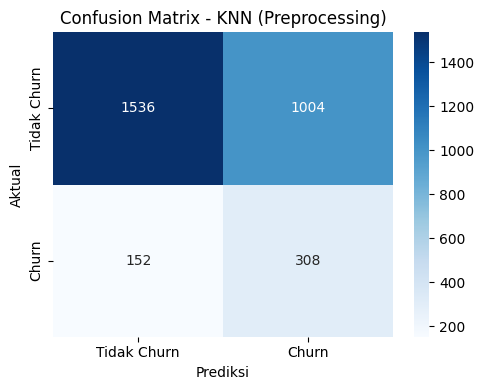


===== Random Forest (Preprocessing) =====
Accuracy : 0.8507
Precision: 0.5104
Recall   : 0.6391
F1 Score : 0.5676

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2540
           1       0.51      0.64      0.57       460

    accuracy                           0.85      3000
   macro avg       0.72      0.76      0.74      3000
weighted avg       0.87      0.85      0.86      3000



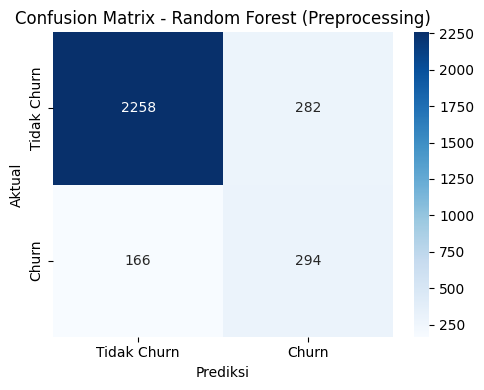


===== Voting Classifier LR+KNN+SVM (Preprocessing) =====
Accuracy : 0.7920
Precision: 0.3758
Recall   : 0.5391
F1 Score : 0.4429

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.84      0.87      2540
           1       0.38      0.54      0.44       460

    accuracy                           0.79      3000
   macro avg       0.64      0.69      0.66      3000
weighted avg       0.83      0.79      0.81      3000



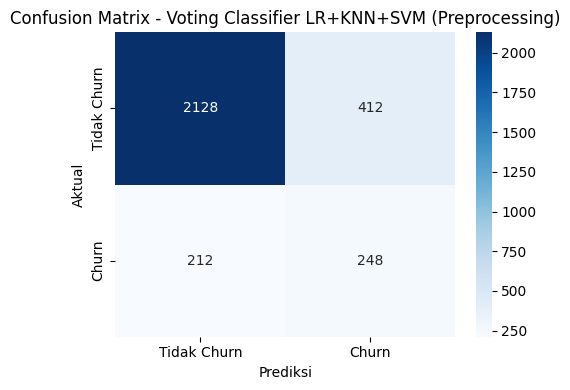


===== Ringkasan Performa dengan Preprocessing =====
                                       Model  Accuracy  Precision   Recall       F1
                         KNN (Preprocessing)  0.614667   0.234756 0.669565 0.347630
               Random Forest (Preprocessing)  0.850667   0.510417 0.639130 0.567568
Voting Classifier LR+KNN+SVM (Preprocessing)  0.792000   0.375758 0.539130 0.442857


In [ ]:
results_prep = []
results_prep.append(evaluate_model(y_test, pred_knn_prep,    'KNN (Preprocessing)'))
results_prep.append(evaluate_model(y_test, pred_rf_prep,     'Random Forest (Preprocessing)'))
results_prep.append(evaluate_model(y_test, pred_voting_prep, 'Voting Classifier LR+KNN+SVM (Preprocessing)'))

print("\n===== Ringkasan Performa dengan Preprocessing =====")
print(pd.DataFrame(results_prep).to_string(index=False))


---
# 4. Hyperparameter Tuning dan Feature Selection

Unit Kompetensi Mengoptimalkan kinerja model melalui hyperparameter tuning menggunakan GridSearchCV
### 4.1 Feature Importance Analysis


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_prep.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Feature Importance:")
print(feature_importance.head(15).to_string(index=False))


Top 15 Feature Importance:
                 Feature  Importance
      satisfaction_score    0.266782
             total_spent    0.207152
         support_tickets    0.050826
             device_type    0.025684
        email_click_rate    0.023631
          lifetime_value    0.023122
marketing_spend_per_user    0.023097
         email_open_rate    0.023091
        avg_session_time    0.021360
         avg_order_value    0.021279
                 country    0.020548
         is_premium_user    0.020323
       pages_per_session    0.020167
          payment_method    0.020143
                     age    0.019490


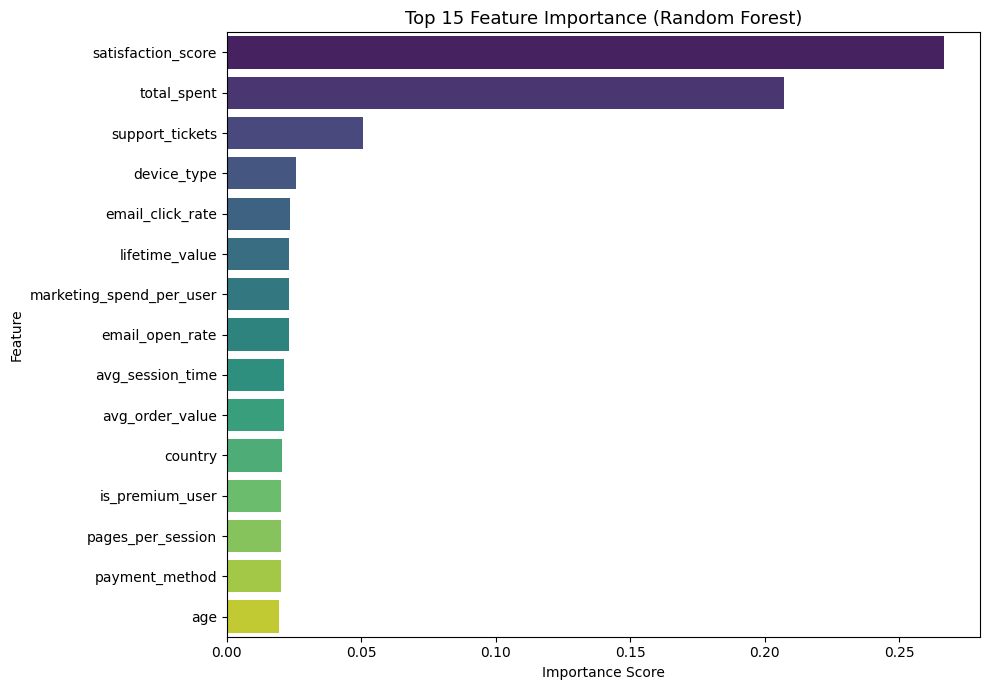

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature',
            data=feature_importance.head(15), palette='viridis')
plt.title('Top 15 Feature Importance (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### 4.2 Feature Selection — Pilih Top 15 Fitur

In [ ]:
top_features = feature_importance.head(15)['Feature'].tolist()
print(f"Fitur terpilih ({len(top_features)}):")
print(top_features)

X_train_sel = X_train_sm[top_features] if hasattr(X_train_sm, '__getitem__') else pd.DataFrame(X_train_sm, columns=X.columns)[top_features]
# Karena X_train_sm dari SMOTE masih numpy array, konversi dulu
X_train_sm_df = pd.DataFrame(X_train_sm, columns=X.columns)
X_test_df     = pd.DataFrame(X_test, columns=X.columns)

X_train_sel = X_train_sm_df[top_features]
X_test_sel  = X_test_df[top_features]

# Standarisasi ulang untuk fitur terpilih
scaler_sel = StandardScaler()
X_train_sel_std = scaler_sel.fit_transform(X_train_sel)
X_test_sel_std  = scaler_sel.transform(X_test_sel)

print(f"\nShape X_train_sel: {X_train_sel.shape}")
print(f"Shape X_test_sel : {X_test_sel.shape}")


Fitur terpilih (15):
['satisfaction_score', 'total_spent', 'support_tickets', 'device_type', 'email_click_rate', 'lifetime_value', 'marketing_spend_per_user', 'email_open_rate', 'avg_session_time', 'avg_order_value', 'country', 'is_premium_user', 'pages_per_session', 'payment_method', 'age']

Shape X_train_sel: (20324, 15)
Shape X_test_sel : (3000, 15)


### 4.3 GridSearchCV — KNN

In [ ]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 11],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_knn.fit(X_train_sel_std, y_train_sm)

print('Best Parameters KNN:')
print(grid_knn.best_params_)
print(f'Best CV F1 Score: {grid_knn.best_score_:.4f}')


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters KNN:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Best CV F1 Score: 0.8830


### 4.4 GridSearchCV — Random Forest

In [ ]:
param_grid_rf = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf' : [1, 2]
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_rf.fit(X_train_sel, y_train_sm)

print('Best Parameters Random Forest:')
print(grid_rf.best_params_)
print(f'Best CV F1 Score: {grid_rf.best_score_:.4f}')


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters Random Forest:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1 Score: 0.8813


### 4.5 GridSearchCV — Voting Classifier (LR + KNN + SVM)

In [ ]:
param_grid_voting = {
    'lr__C'           : [0.1, 1.0],
    'knn__n_neighbors': [3, 5]
}

voting_tune = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression()),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True))      # SVM
    ],
    voting='soft'
)

grid_voting = GridSearchCV(
    estimator=voting_tune,
    param_grid=param_grid_voting,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid_voting.fit(X_train_sel_std, y_train_sm)

print('Best Parameters Voting Classifier (LR+KNN+SVM):')
print(grid_voting.best_params_)
print(f'Best CV F1 Score: {grid_voting.best_score_:.4f}')

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Parameters Voting Classifier (LR+KNN+SVM):
{'knn__n_neighbors': 3, 'lr__C': 1.0}
Best CV F1 Score: 0.8831


### 4.6 Best Estimator — Latih Ulang dan Evaluasi

In [ ]:
best_knn    = grid_knn.best_estimator_
best_rf     = grid_rf.best_estimator_
best_voting = grid_voting.best_estimator_

pred_knn_tuned    = best_knn.predict(X_test_sel_std)
pred_rf_tuned     = best_rf.predict(X_test_sel)
pred_voting_tuned = best_voting.predict(X_test_sel_std)

print("Best estimator diperoleh dan prediksi selesai.")


Best estimator diperoleh dan prediksi selesai.



===== KNN (Tuned) =====
Accuracy : 0.7370
Precision: 0.3124
Recall   : 0.5957
F1 Score : 0.4099

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      2540
           1       0.31      0.60      0.41       460

    accuracy                           0.74      3000
   macro avg       0.61      0.68      0.62      3000
weighted avg       0.82      0.74      0.77      3000



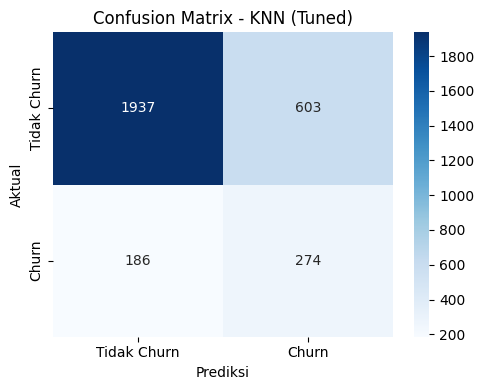


===== Random Forest (Tuned) =====
Accuracy : 0.8507
Precision: 0.5094
Recall   : 0.7065
F1 Score : 0.5920

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      2540
           1       0.51      0.71      0.59       460

    accuracy                           0.85      3000
   macro avg       0.73      0.79      0.75      3000
weighted avg       0.88      0.85      0.86      3000



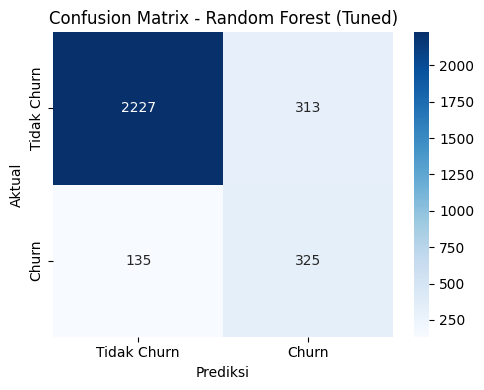


===== Voting Classifier LR+KNN+SVM (Tuned) =====
Accuracy : 0.8020
Precision: 0.4130
Recall   : 0.6913
F1 Score : 0.5171

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      2540
           1       0.41      0.69      0.52       460

    accuracy                           0.80      3000
   macro avg       0.67      0.76      0.70      3000
weighted avg       0.86      0.80      0.82      3000



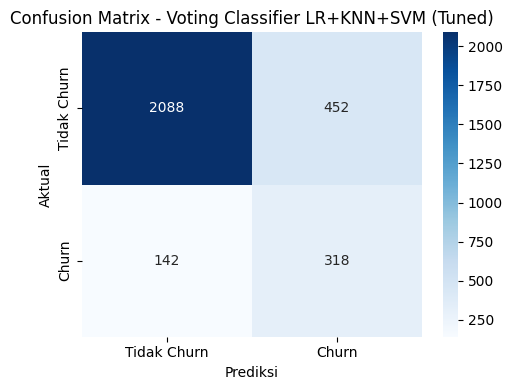


===== Ringkasan Performa Hyperparameter Tuning =====
                               Model  Accuracy  Precision   Recall       F1
                         KNN (Tuned)  0.737000   0.312429 0.595652 0.409873
               Random Forest (Tuned)  0.850667   0.509404 0.706522 0.591985
Voting Classifier LR+KNN+SVM (Tuned)  0.802000   0.412987 0.691304 0.517073


In [ ]:
results_tuned = []
results_tuned.append(evaluate_model(y_test, pred_knn_tuned,    'KNN (Tuned)'))
results_tuned.append(evaluate_model(y_test, pred_rf_tuned,     'Random Forest (Tuned)'))
results_tuned.append(evaluate_model(y_test, pred_voting_tuned, 'Voting Classifier LR+KNN+SVM (Tuned)'))

print("\n===== Ringkasan Performa Hyperparameter Tuning =====")
print(pd.DataFrame(results_tuned).to_string(index=False))


---
# 5. Perbandingan Model: KNN vs Random Forest vs SVM

Tujuan Membandingkan performa tiga model secara individual(standalone) pada kondisi yang sama:
data hasil preprocessing + SMOTE + Standarisasi, tanpa hyperparameter tuning

| Model | Kategori |
|-------|----------|
| KNN | Konvensional (berbasis jarak) |
| Random Forest| Ensemble Bagging (berbasis pohon) |
| SVM | Konvensional (berbasis margin/kernel) |


### 5.1 Latih Ketiga Model pada Data yang Sama

In [ ]:
# KNN
knn_cmp = KNeighborsClassifier()
knn_cmp.fit(X_train_std, y_train_sm)
pred_knn_cmp = knn_cmp.predict(X_test_std)
print("KNN — Selesai dilatih")

# Random Forest
rf_cmp = RandomForestClassifier(random_state=42)
rf_cmp.fit(X_train_sm, y_train_sm)
pred_rf_cmp = rf_cmp.predict(X_test)
print("Random Forest — Selesai dilatih")

# SVM
svm_cmp = SVC(probability=True, random_state=42)
svm_cmp.fit(X_train_std, y_train_sm)
pred_svm_cmp = svm_cmp.predict(X_test_std)
print("SVM — Selesai dilatih")


KNN — Selesai dilatih
Random Forest — Selesai dilatih
SVM — Selesai dilatih


### 5.2 Evaluasi Masing-Masing Model


===== KNN =====
Accuracy : 0.6147
Precision: 0.2348
Recall   : 0.6696
F1 Score : 0.3476

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.60      0.73      2540
           1       0.23      0.67      0.35       460

    accuracy                           0.61      3000
   macro avg       0.57      0.64      0.54      3000
weighted avg       0.81      0.61      0.67      3000



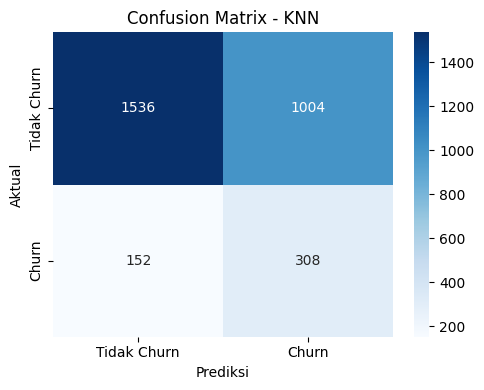


===== Random Forest =====
Accuracy : 0.8507
Precision: 0.5104
Recall   : 0.6391
F1 Score : 0.5676

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      2540
           1       0.51      0.64      0.57       460

    accuracy                           0.85      3000
   macro avg       0.72      0.76      0.74      3000
weighted avg       0.87      0.85      0.86      3000



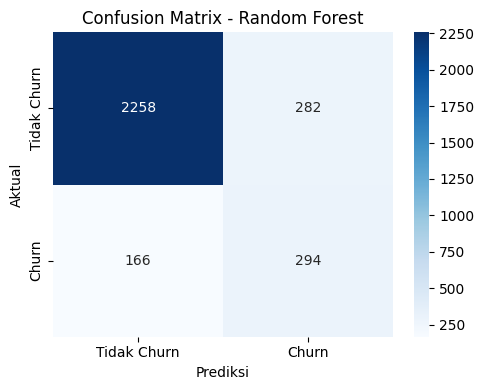


===== SVM =====
Accuracy : 0.8290
Precision: 0.4458
Recall   : 0.4739
F1 Score : 0.4594

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      2540
           1       0.45      0.47      0.46       460

    accuracy                           0.83      3000
   macro avg       0.67      0.68      0.68      3000
weighted avg       0.83      0.83      0.83      3000



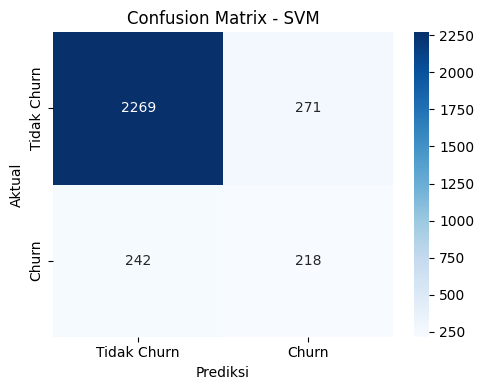

In [ ]:
def evaluate_model(y_true, y_pred, model_name):
    print(f'\n===== {model_name} =====')
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1 Score : {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Tidak Churn', 'Churn'],
                yticklabels=['Tidak Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Prediksi')
    plt.ylabel('Aktual')
    plt.tight_layout()
    plt.show()

    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

results_cmp = []
results_cmp.append(evaluate_model(y_test, pred_knn_cmp, 'KNN'))
results_cmp.append(evaluate_model(y_test, pred_rf_cmp,  'Random Forest'))
results_cmp.append(evaluate_model(y_test, pred_svm_cmp, 'SVM'))

### 5.3 Tabel Perbandingan KNN vs Random Forest vs SVM

In [ ]:
df_cmp = pd.DataFrame(results_cmp)
df_cmp = df_cmp.set_index('Model')

print("=" * 60)
print("   PERBANDINGAN: KNN vs Random Forest vs SVM")
print("=" * 60)
print(df_cmp.to_string())
print("=" * 60)

# Tandai nilai terbaik tiap metrik
for col in df_cmp.columns:
    best_val = df_cmp[col].max()
    best_mdl = df_cmp[col].idxmax()
    print(f"  🏆 {col} terbaik : {best_mdl} ({best_val:.4f})")


   PERBANDINGAN: KNN vs Random Forest vs SVM
               Accuracy  Precision    Recall        F1
Model                                                 
KNN            0.614667   0.234756  0.669565  0.347630
Random Forest  0.850667   0.510417  0.639130  0.567568
SVM            0.829000   0.445808  0.473913  0.459431
  🏆 Accuracy terbaik : Random Forest (0.8507)
  🏆 Precision terbaik : Random Forest (0.5104)
  🏆 Recall terbaik : KNN (0.6696)
  🏆 F1 terbaik : Random Forest (0.5676)


### 5.4 Grafik Perbandingan KNN vs Random Forest vs SVM

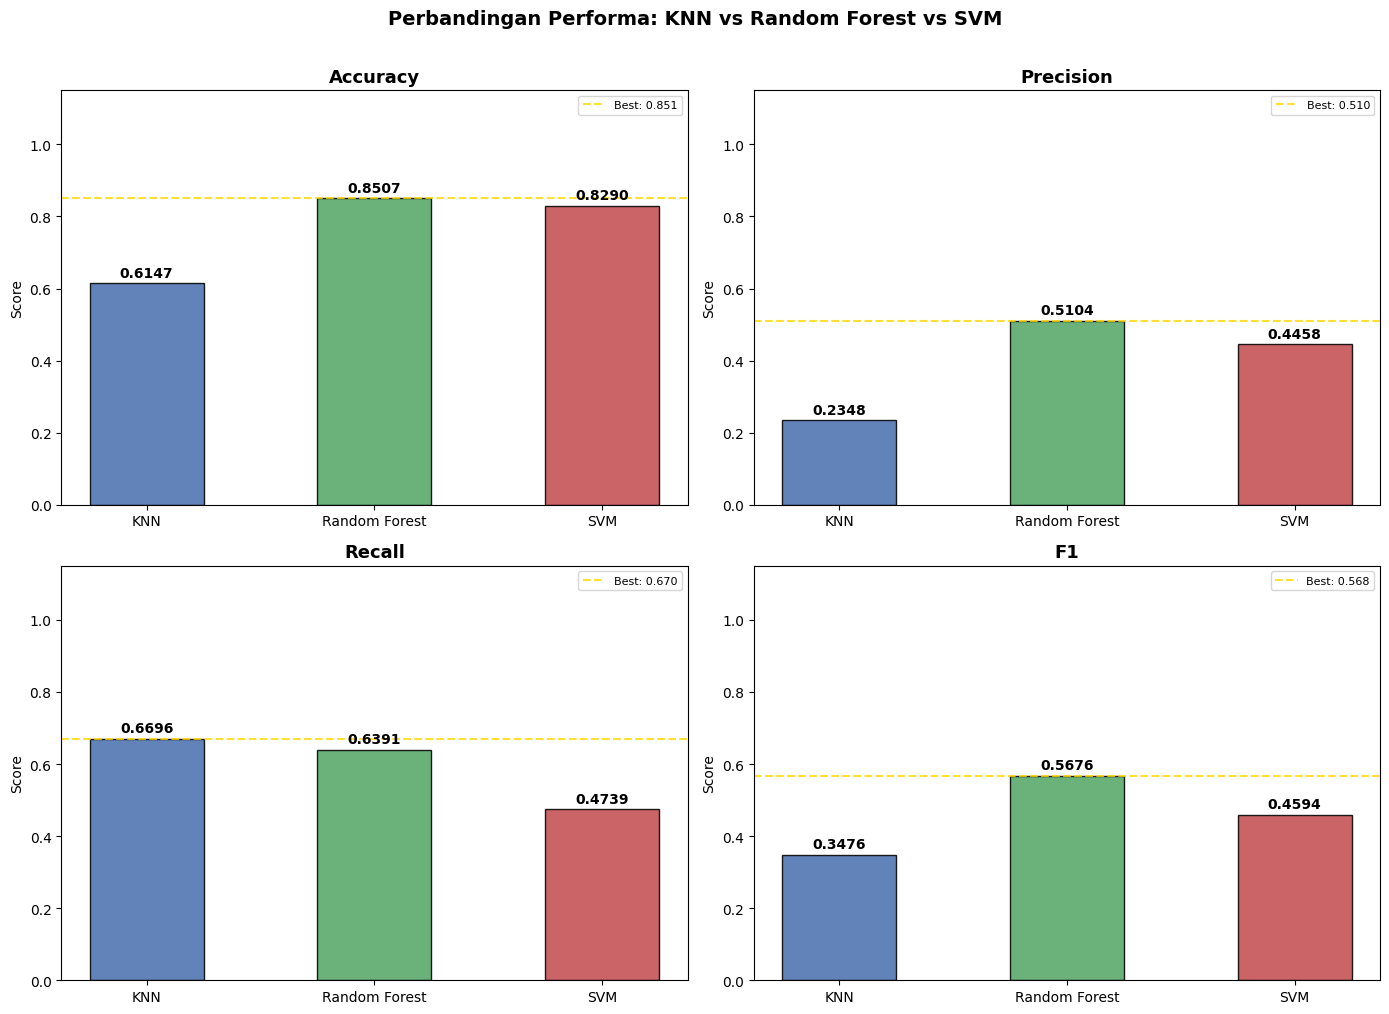

In [ ]:
df_cmp_plot = pd.DataFrame(results_cmp)
metrics     = ['Accuracy', 'Precision', 'Recall', 'F1']
model_names = df_cmp_plot['Model'].tolist()
colors_cmp  = ['#4C72B0', '#55A868', '#C44E52']   # biru, hijau, merah

# ── 1. Grouped Bar Chart per Metrik ──────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric in zip(axes.flatten(), metrics):
    vals = df_cmp_plot[metric].values
    bars = ax.bar(model_names, vals, color=colors_cmp, edgecolor='black',
                  width=0.5, alpha=0.88)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.axhline(y=max(vals), color='gold', linestyle='--', linewidth=1.5,
               alpha=0.8, label=f'Best: {max(vals):.3f}')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.suptitle('Perbandingan Performa: KNN vs Random Forest vs SVM',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


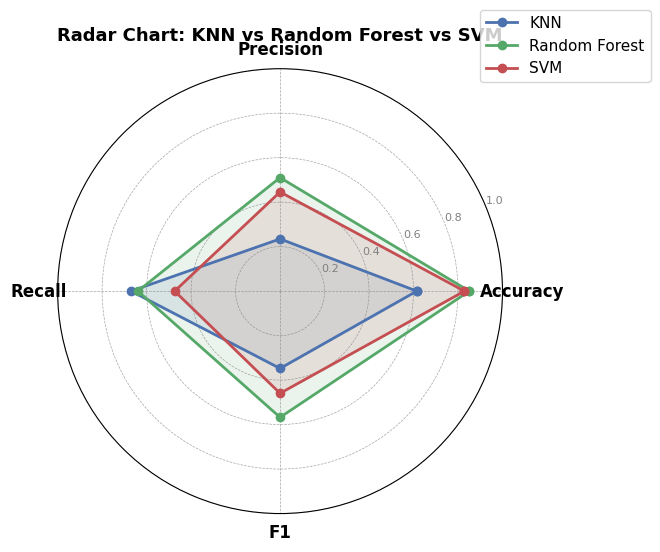

In [ ]:
# ── 2. Radar / Spider Chart ───────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = metrics
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # tutup lingkaran

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

model_colors = ['#4C72B0', '#55A868', '#C44E52']

for idx, row in df_cmp_plot.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2,
            label=row['Model'], color=model_colors[idx])
    ax.fill(angles, values, alpha=0.12, color=model_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=8, color='grey')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_title('Radar Chart: KNN vs Random Forest vs SVM',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)
plt.tight_layout()
plt.show()


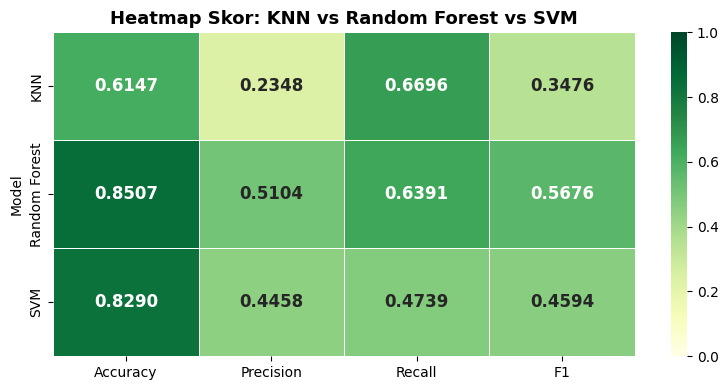

In [ ]:
# ── 3. Heatmap Skor ──────────────────────────────
df_heat = df_cmp_plot.set_index('Model')[metrics]

plt.figure(figsize=(8, 4))
sns.heatmap(df_heat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, vmin=0, vmax=1,
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title('Heatmap Skor: KNN vs Random Forest vs SVM',
          fontsize=13, fontweight='bold')
plt.ylabel('Model')
plt.tight_layout()
plt.show()


### 5.5 Kesimpulan Perbandingan

In [ ]:
df_cmp_plot['Total Score'] = df_cmp_plot[metrics].sum(axis=1)
df_cmp_plot_sorted = df_cmp_plot.sort_values('Total Score', ascending=False).reset_index(drop=True)

print("=" * 55)
print("   RANKING MODEL (berdasarkan Total Score)")
print("=" * 55)
for rank, row in df_cmp_plot_sorted.iterrows():
    medal = ['🥇','🥈','🥉'][rank]
    print(f"  {medal} Rank {rank+1}: {row['Model']}")
    print(f"       Accuracy : {row['Accuracy']:.4f}")
    print(f"       Precision: {row['Precision']:.4f}")
    print(f"       Recall   : {row['Recall']:.4f}")
    print(f"       F1 Score : {row['F1']:.4f}")
    print(f"       Total    : {row['Total Score']:.4f}")
    print()

best_model_cmp = df_cmp_plot_sorted.iloc[0]['Model']
print(f"Model terbaik dari perbandingan ini: {best_model_cmp}")
print()
print(" Karakteristik masing-masing model:")
print("   KNN          — Sederhana, sensitif terhadap skala fitur & jumlah tetangga")
print("   Random Forest — Robust, tidak perlu scaling, baik untuk data tidak linear")
print("   SVM          — Efektif di ruang berdimensi tinggi, sensitif terhadap scaling")


   RANKING MODEL (berdasarkan Total Score)
  🥇 Rank 1: Random Forest
       Accuracy : 0.8507
       Precision: 0.5104
       Recall   : 0.6391
       F1 Score : 0.5676
       Total    : 2.5678

  🥈 Rank 2: SVM
       Accuracy : 0.8290
       Precision: 0.4458
       Recall   : 0.4739
       F1 Score : 0.4594
       Total    : 2.2082

  🥉 Rank 3: KNN
       Accuracy : 0.6147
       Precision: 0.2348
       Recall   : 0.6696
       F1 Score : 0.3476
       Total    : 1.8666

Model terbaik dari perbandingan ini: Random Forest

 Karakteristik masing-masing model:
   KNN          — Sederhana, sensitif terhadap skala fitur & jumlah tetangga
   Random Forest — Robust, tidak perlu scaling, baik untuk data tidak linear
   SVM          — Efektif di ruang berdimensi tinggi, sensitif terhadap scaling


---
# 6. Perbandingan Semua 9 Model dan Identifikasi Model Terbaik

In [ ]:
all_results = results_direct + results_prep + results_tuned
df_all = pd.DataFrame(all_results)

print("===== Perbandingan Performa Semua Model (9 Model) =====")
print(df_all.to_string(index=False))

best_idx = df_all['F1'].idxmax()
print(f"\nModel Terbaik (F1 tertinggi):")
print(df_all.iloc[best_idx])


===== Perbandingan Performa Semua Model (9 Model) =====
                                       Model  Accuracy  Precision   Recall       F1
                                KNN (Direct)  0.843667   0.480000 0.234783 0.315328
                      Random Forest (Direct)  0.850333   0.518900 0.328261 0.402130
       Voting Classifier LR+KNN+SVM (Direct)  0.850000   0.619048 0.056522 0.103586
                         KNN (Preprocessing)  0.614667   0.234756 0.669565 0.347630
               Random Forest (Preprocessing)  0.850667   0.510417 0.639130 0.567568
Voting Classifier LR+KNN+SVM (Preprocessing)  0.792000   0.375758 0.539130 0.442857
                                 KNN (Tuned)  0.737000   0.312429 0.595652 0.409873
                       Random Forest (Tuned)  0.850667   0.509404 0.706522 0.591985
        Voting Classifier LR+KNN+SVM (Tuned)  0.802000   0.412987 0.691304 0.517073

Model Terbaik (F1 tertinggi):
Model        Random Forest (Tuned)
Accuracy                  0.850667
Pre

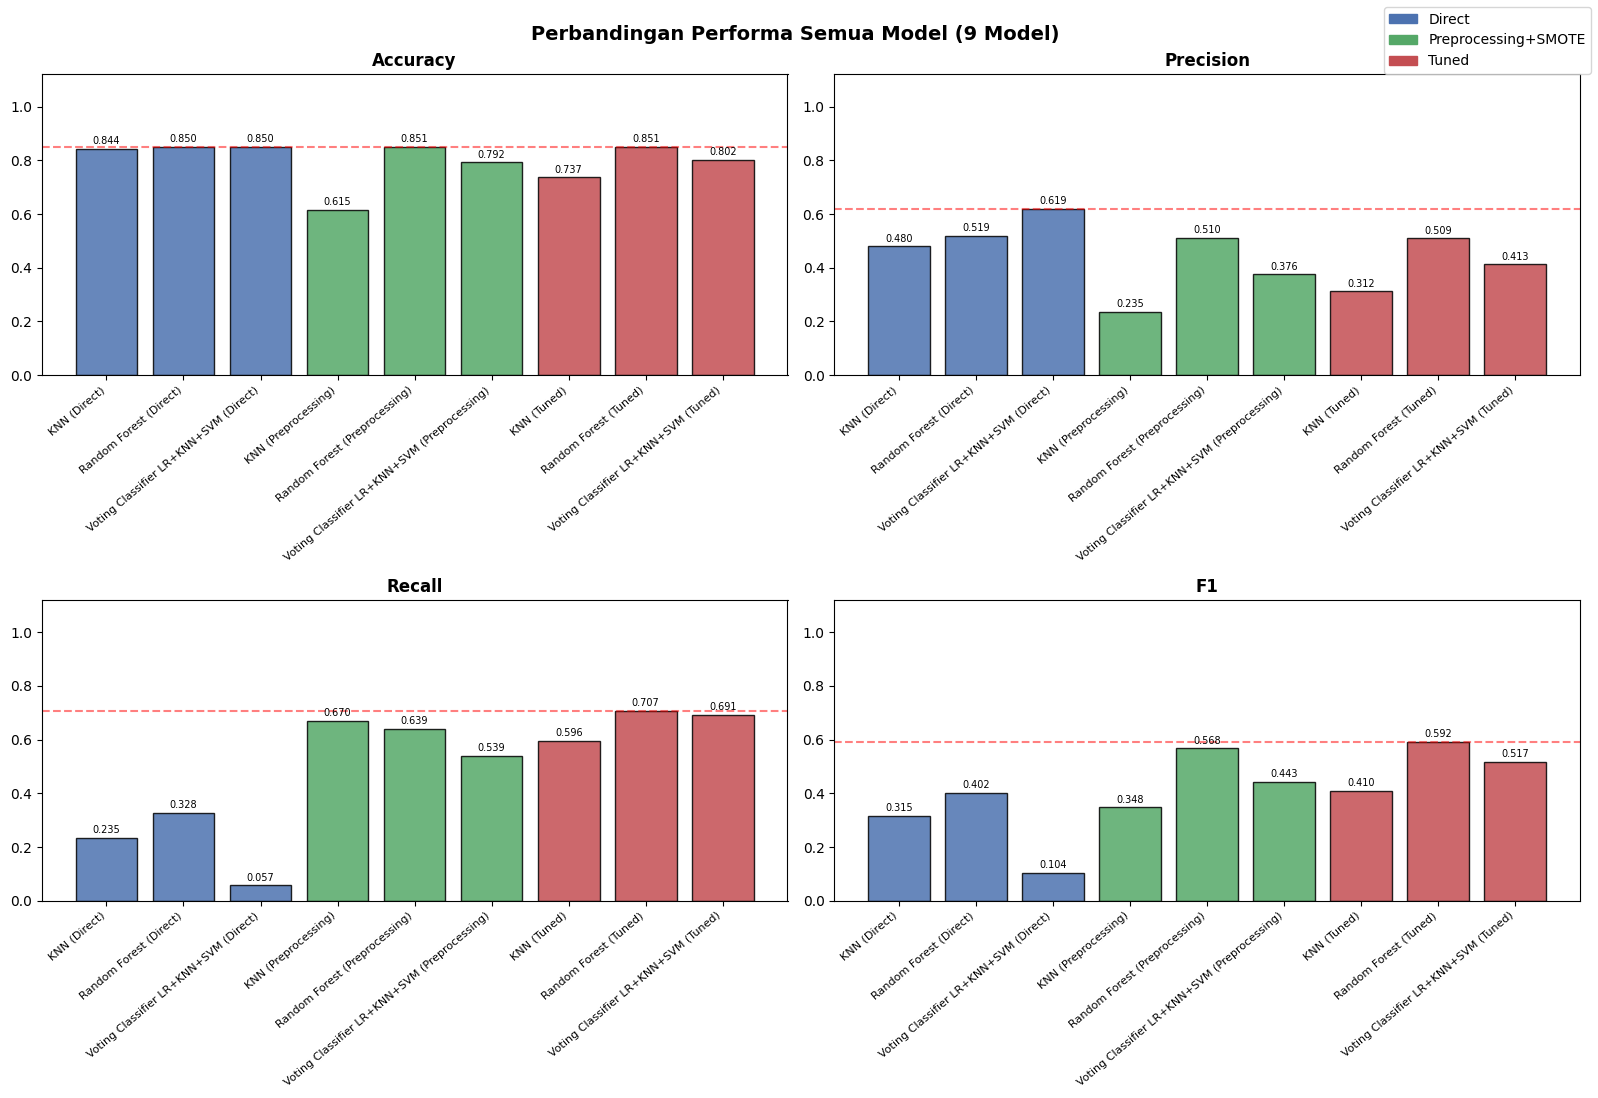

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors  = ['#4C72B0']*3 + ['#55A868']*3 + ['#C44E52']*3

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.bar(range(len(df_all)), df_all[metric], color=colors,
                  edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(df_all)))
    ax.set_xticklabels(df_all['Model'], rotation=40, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.axhline(y=df_all[metric].max(), color='red', linestyle='--', alpha=0.5, label='Best')
    for bar, val in zip(bars, df_all[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(color='#4C72B0', label='Direct'),
              Patch(color='#55A868', label='Preprocessing+SMOTE'),
              Patch(color='#C44E52', label='Tuned')]
fig.legend(handles=legend_els, loc='upper right', fontsize=10)
plt.suptitle('Perbandingan Performa Semua Model (9 Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
best_model_name = df_all.loc[df_all['F1'].idxmax(), 'Model']
print(f"Model terbaik: {best_model_name}")

# Tentukan model dan scaler yang dipakai
if 'Random Forest (Tuned)' in best_model_name:
    best_model = best_rf;      use_scaler = None;          use_cols = top_features
elif 'KNN (Tuned)' in best_model_name:
    best_model = best_knn;     use_scaler = scaler_sel;    use_cols = top_features
elif 'Voting' in best_model_name and 'Tuned' in best_model_name:
    best_model = best_voting;  use_scaler = scaler_sel;    use_cols = top_features
elif 'Random Forest' in best_model_name:
    best_model = rf_prep;      use_scaler = None;          use_cols = list(X.columns)
elif 'KNN' in best_model_name:
    best_model = knn_prep;     use_scaler = scaler_std;    use_cols = list(X.columns)
else:
    best_model = voting_prep;  use_scaler = scaler_std;    use_cols = list(X.columns)

# Simpan artefak
joblib.dump(best_model,     'best_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(use_cols,       'feature_columns.pkl')
if use_scaler:
    joblib.dump(use_scaler, 'scaler.pkl')

print("\nArtefak berhasil disimpan:")
print("best_model.pkl")
print("label_encoders.pkl")
print("feature_columns.pkl")
if use_scaler:
    print("scaler.pkl")


Model terbaik: Random Forest (Tuned)

Artefak berhasil disimpan:
best_model.pkl
label_encoders.pkl
feature_columns.pkl
